In [ ]:
# # Uncomment on Colab

# !pip install exponax optax chaotax

In [2]:
import jax
import jax.numpy as jnp
import exponax as ex
import optax
import matplotlib.pyplot as plt
import chaotax

Let's reuse the same setup of before!

In [3]:
DT = 0.1
NUM_SUBSTEPS = 10
RESOLUTION_FULL = 128
DIFFUSIVITY = 1e-2

stepper = ex.RepeatedStepper(
    ex.stepper.KolmogorovFlowVorticity(
        2,
        2 * jnp.pi,
        RESOLUTION_FULL,
        DT / NUM_SUBSTEPS,
        diffusivity=DIFFUSIVITY,
        order=4,
    ),
    NUM_SUBSTEPS,
)

In [4]:
ic = jax.random.normal(
    jax.random.key(0),
    (1, 128, 128),
)

In [5]:
warmed_ic = ex.repeat(stepper, 1000)(ic)

Solves the optimization problem over $n$ rollout steps

$$
u^*_0 = \arg\min_{u_0} 1/2 \|\mathcal{P}_h^n(u_0) - y\|^2
$$

Whereas we created the target artificially via

$$
y = \mathcal{P}_h^n(u_0^{\text{true}})
$$

while $u_0^{\text{true}}$ is just the `warmed_ic` of before.

We will initialize the optimization with a noised version of the true initial condition, i.e.
$$
u_0 = u_0^{\text{true}} + \epsilon
$$
where $\epsilon$ is Gaussian noise.

Notice, the backpropagation through time that we get

$$
\left(\frac{\partial L}{\partial u_0}\right)^T = (\mathcal{P}_h^n(u_0) - y)^T \prod_{i=n-1}^{0} \frac{\partial \mathcal{P}_h}{\partial u}\bigg|_{\mathcal{P}_h^i(u_0)}
$$

In [6]:
# initial_guess = jnp.zeros_like(warmed_ic)
LEARNING_RATE = 0.5
NUM_ROLLOUT_STEPS = 1
DISTURBING_SCALE = 3.0

initial_guess = warmed_ic + DISTURBING_SCALE * jax.random.normal(
    jax.random.key(1), warmed_ic.shape
)

learned_ic = initial_guess


target = ex.repeat(stepper, NUM_ROLLOUT_STEPS)(warmed_ic)

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(learned_ic)


def loss_fn(current_ic):
    prediction = ex.repeat(stepper, NUM_ROLLOUT_STEPS)(current_ic)
    return jnp.mean((prediction - target) ** 2)


@jax.jit
def update(current_ic, state):
    loss, grad = jax.value_and_grad(loss_fn)(current_ic)
    rel_optimality_error = jnp.linalg.norm(current_ic - warmed_ic) / jnp.linalg.norm(
        warmed_ic
    )
    updates, new_state = optimizer.update(
        grad, state, current_ic, value=loss, grad=grad, value_fn=loss_fn
    )
    new_ic = optax.apply_updates(current_ic, updates)
    return new_ic, new_state, loss, rel_optimality_error


loss_history = []
rel_optimality_error_history = []

for step in range(1000):
    learned_ic, opt_state, loss, rel_optimality_error = update(learned_ic, opt_state)
    loss_history.append(loss)
    rel_optimality_error_history.append(rel_optimality_error)
    if step % 25 == 0:
        print(
            f"Step {step}, Loss: {loss:.4e}, Relative Optimality Error: {rel_optimality_error:.4e}"
        )

Step 0, Loss: 8.4652e-01, Relative Optimality Error: 8.8317e-01
Step 25, Loss: 2.3668e-02, Relative Optimality Error: 6.5213e-01
Step 50, Loss: 4.2761e-03, Relative Optimality Error: 5.8341e-01
Step 75, Loss: 1.7096e-03, Relative Optimality Error: 5.4392e-01
Step 100, Loss: 1.0516e-03, Relative Optimality Error: 5.1536e-01
Step 125, Loss: 7.4401e-04, Relative Optimality Error: 4.9262e-01
Step 150, Loss: 5.5963e-04, Relative Optimality Error: 4.7362e-01
Step 175, Loss: 4.3708e-04, Relative Optimality Error: 4.5730e-01
Step 200, Loss: 3.5066e-04, Relative Optimality Error: 4.4300e-01
Step 225, Loss: 2.8715e-04, Relative Optimality Error: 4.3031e-01
Step 250, Loss: 2.3900e-04, Relative Optimality Error: 4.1893e-01
Step 275, Loss: 2.0157e-04, Relative Optimality Error: 4.0863e-01
Step 300, Loss: 1.7190e-04, Relative Optimality Error: 3.9925e-01
Step 325, Loss: 1.4852e-04, Relative Optimality Error: 3.9066e-01
Step 350, Loss: 5.1622e-04, Relative Optimality Error: 3.8320e-01
Step 375, Loss:

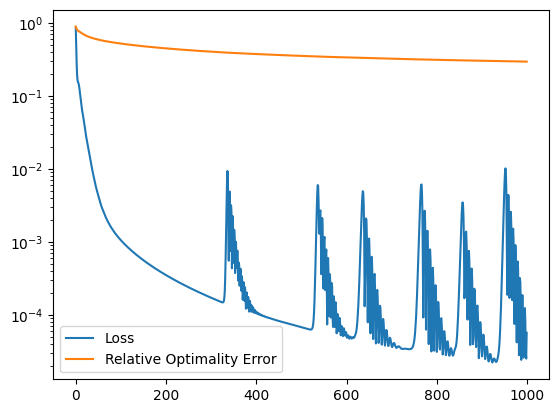

In [7]:
plt.semilogy(loss_history, label="Loss")
plt.semilogy(rel_optimality_error_history, label="Relative Optimality Error")
plt.legend()

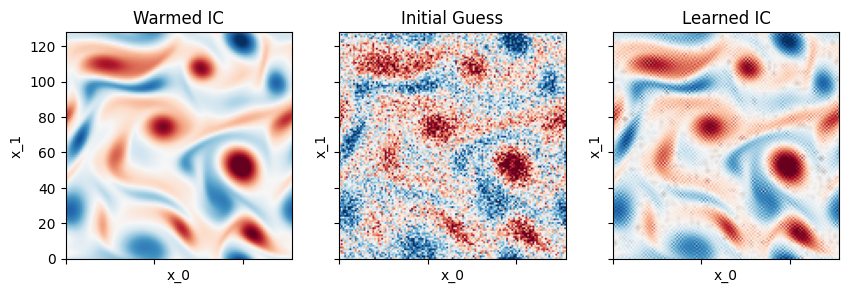

In [8]:
stacked = jnp.stack([warmed_ic, initial_guess, learned_ic])
ex.viz.plot_state_2d_facet(
    stacked,
    vlim=(-10, 10),
    facet_over_channels=False,
    titles=["Warmed IC", "Initial Guess", "Learned IC"],
)

To put this into context, let's compute the Lyapunov time, which gives us a good order of magnitude for how long backpropagation through time is going to work for chaotic systems (like here).

Feel free to check out the docs here: https://fkoehler.site/chaotax/api.html


In [ ]:
# This is a function transformation, similar to `ex.rollout`
lyapunov_exponent = chaotax.lyapunov(
    stepper, rollout_steps=1000, warmup_steps=0, discard_steps=200
)(warmed_ic, key=jax.random.key(0))

In [10]:
1.0 / lyapunov_exponent

Array(24.393744, dtype=float32)

Now let's solve another data assimimilation problem: identifying the diffusivity $\nu$ from the trajectory.

$$
\nu^* = \arg\min_{\nu} 1/2 \sum_{i=1}^n \|\mathcal{P}^i_h(u_0; \nu) - y_i\|^2
$$

Where $\mathcal{P}^i_h(u_0; \nu)$ is the $i$-th rollout step of the time stepper with diffusivity $\nu$ and $y_i$ is the target state at time step $i$.

Note that we not only get the bptt, but also a gradient contribution from each time step into the diffusivity $\nu$.

In [11]:
def build_stepper(diff):
    return ex.RepeatedStepper(
        ex.stepper.KolmogorovFlowVorticity(
            2,
            2 * jnp.pi,
            RESOLUTION_FULL,
            DT / NUM_SUBSTEPS,
            diffusivity=diff,
            order=4,
        ),
        NUM_SUBSTEPS,
    )


LEARNING_RATE = 0.01
NUM_ROLLOUT_STEPS = 3
NUM_OPT_STEPS = 100

initial_guess = 0.1
learned_diffusivity = initial_guess

target_trj = ex.rollout(stepper, NUM_ROLLOUT_STEPS)(warmed_ic)

optimizer = optax.adam(LEARNING_RATE, nesterov=True)
opt_state = optimizer.init(initial_guess)


def loss_fn_diffusivity(current_diffusivity):
    current_stepper = build_stepper(current_diffusivity)
    prediction_trj = ex.rollout(current_stepper, NUM_ROLLOUT_STEPS)(warmed_ic)
    return jnp.mean((prediction_trj - target_trj) ** 2)


@jax.jit
def update_diffusivity(current_diffusivity, state):
    loss, grad = jax.value_and_grad(loss_fn_diffusivity)(current_diffusivity)
    rel_optimality_error = jnp.linalg.norm(
        current_diffusivity - DIFFUSIVITY
    ) / jnp.linalg.norm(DIFFUSIVITY)
    updates, new_state = optimizer.update(grad, state, current_diffusivity)
    new_diffusivity = optax.apply_updates(current_diffusivity, updates)
    return new_diffusivity, new_state, loss, rel_optimality_error


loss_history = []
rel_optimality_error_history = []

for step in range(NUM_OPT_STEPS):
    learned_diffusivity, opt_state, loss, rel_optimality_error = update_diffusivity(
        learned_diffusivity, opt_state
    )
    loss_history.append(loss)
    rel_optimality_error_history.append(rel_optimality_error)
    if step % 10 == 0:
        print(
            f"Step {step}, Loss: {loss:.4e}, Relative Optimality Error: {rel_optimality_error:.4e}"
        )

Step 0, Loss: 1.0016e+00, Relative Optimality Error: 9.0000e+00
Step 10, Loss: 4.5714e-02, Relative Optimality Error: 8.8856e-01
Step 20, Loss: 5.9982e-03, Relative Optimality Error: 4.0434e-01
Step 30, Loss: 6.8733e-04, Relative Optimality Error: 1.2700e-01
Step 40, Loss: 1.0772e-04, Relative Optimality Error: 5.1651e-02
Step 50, Loss: 1.5218e-05, Relative Optimality Error: 1.9216e-02
Step 60, Loss: 1.3259e-06, Relative Optimality Error: 5.6901e-03
Step 70, Loss: 3.4089e-08, Relative Optimality Error: 9.1251e-04
Step 80, Loss: 5.7186e-10, Relative Optimality Error: 1.1632e-04
Step 90, Loss: 4.4621e-10, Relative Optimality Error: 1.0151e-04


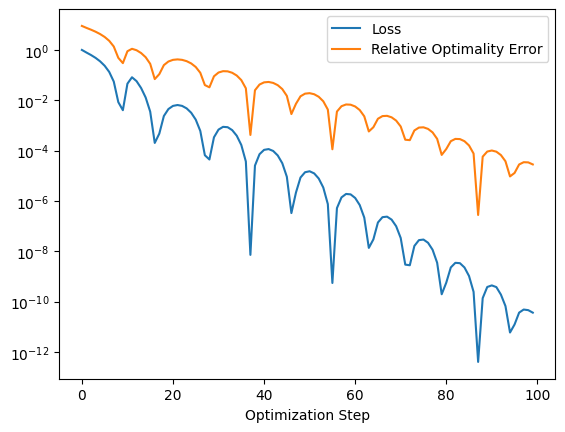

In [12]:
plt.semilogy(loss_history, label="Loss")
plt.semilogy(rel_optimality_error_history, label="Relative Optimality Error")
plt.xlabel("Optimization Step")
plt.legend()